In [1]:
from neo4j_queries import Neo4jQueries
from tabulate import tabulate
import numpy as np

In [ ]:
neo4j_uri = "neo4j+s://fa5d78e1.databases.neo4j.io"
neo4j_user = "neo4j"
neo4j_pass = "t2l0UlomQbkdTBatbfIVsduhg9E2XRYljtkR5PFcT6A"

queries = Neo4jQueries(neo4j_uri, neo4j_user, neo4j_pass)

In [ ]:
top_cities = queries.query_top_cities_by_avg_aqi("2024-01-01", "2024-12-31")
print("Top Cities by Avg AQI:")
print(tabulate(top_cities, headers=["City", "Country", "Avg AQI"], tablefmt="pretty"))

Top Cities by Avg AQI:
+-------------+---------+---------+
|    City     | Country | Avg AQI |
+-------------+---------+---------+
|    Delhi    |  India  | 170.58  |
|  São Paulo  | Brazil  | 168.77  |
| Los Angeles |   USA   | 167.75  |
|    Cairo    |  Egypt  | 166.06  |
|    Paris    | France  | 162.16  |
+-------------+---------+---------+


In [4]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [5]:
import matplotlib.pyplot as plt

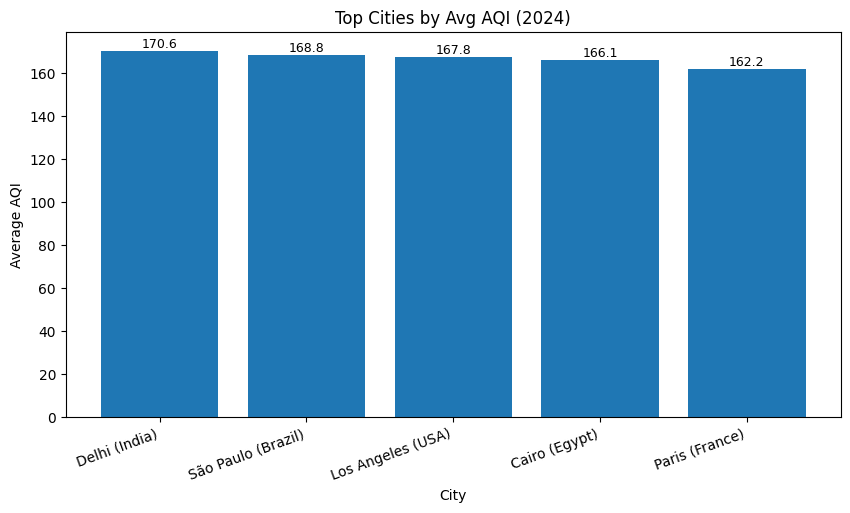

In [6]:
def plot_top_cities_avg_aqi(top_cities, title="Top Cities by Avg AQI (2024)"):
    cities  = [f"{c} ({ctry})" for c, ctry, _ in top_cities]
    values  = [v for _, _, v in top_cities]

    plt.figure(figsize=(10, 5))
    plt.bar(cities, values)
    plt.title(title)
    plt.xlabel("City")
    plt.ylabel("Average AQI")
    plt.xticks(rotation=20, ha="right")
    for i, v in enumerate(values):
        plt.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    plt.show()
top_cities = queries.query_top_cities_by_avg_aqi("2024-01-01", "2024-12-31")
plot_top_cities_avg_aqi(top_cities)


In [ ]:
top_pollution_driver = queries.query_pollution_driver_per_city(start_date="2024-01-01",
end_date="2024-12-31",limit=9)
print("\nTop Pollution Driver per City in 2024:")
grouped_table = []
for rec in  top_pollution_driver:
    city = rec["city"]

    items = [
        ("pm25", rec["pm25"]),
        ("pm10", rec["pm10"]),
        ("no2",  rec["no2"]),
        ("o3",   rec["o3"]),
        ("so2",  rec["so2"]),
        ("co",   rec["co"]),
    ]
    items.sort(key=lambda x: x[1], reverse=True)
    
    first = True
    for pol, days in items:
        grouped_table.append([city if first else "", pol, days])
        first = False
    
from tabulate import tabulate
print(tabulate(grouped_table, headers=["City", "Pollutant", "Severe Days"], tablefmt="pretty"))


Top Pollution Driver per City in 2024:
+-------------+-----------+-------------+
|    City     | Pollutant | Severe Days |
+-------------+-----------+-------------+
|  New York   |   pm25    |     351     |
|             |   pm10    |     332     |
|             |    no2    |     313     |
|             |    o3     |     300     |
|             |    so2    |     238     |
|             |    co     |     217     |
|    Delhi    |   pm25    |     349     |
|             |   pm10    |     332     |
|             |    no2    |     303     |
|             |    o3     |     295     |
|             |    so2    |     247     |
|             |    co     |     223     |
|    Paris    |   pm25    |     353     |
|             |   pm10    |     320     |
|             |    no2    |     314     |
|             |    o3     |     286     |
|             |    co     |     222     |
|             |    so2    |     220     |
| Los Angeles |   pm25    |     350     |
|             |   pm10    |     317 

In [ ]:
def plot_pollution_driver_grouped_by_pollutant(rows, title="Pollution Drivers by Pollutant"):
    pollutants = ["pm25","pm10","no2","o3","so2","co"]
    cities = [r["city"] for r in rows]
    values = np.array([[r[p] for p in pollutants] for r in rows])

    x = np.arange(len(pollutants)) 
    width = 0.12

    plt.figure(figsize=(14, 6))
    for i, city in enumerate(cities):
        plt.bar(x + i*width, values[i], width, label=city)

    plt.xticks(x + width*len(cities)/2, pollutants)
    plt.ylabel("Days exceeding WHO guideline")
    plt.title(title)
    plt.legend(title="City")
    plt.tight_layout()
    plt.show()


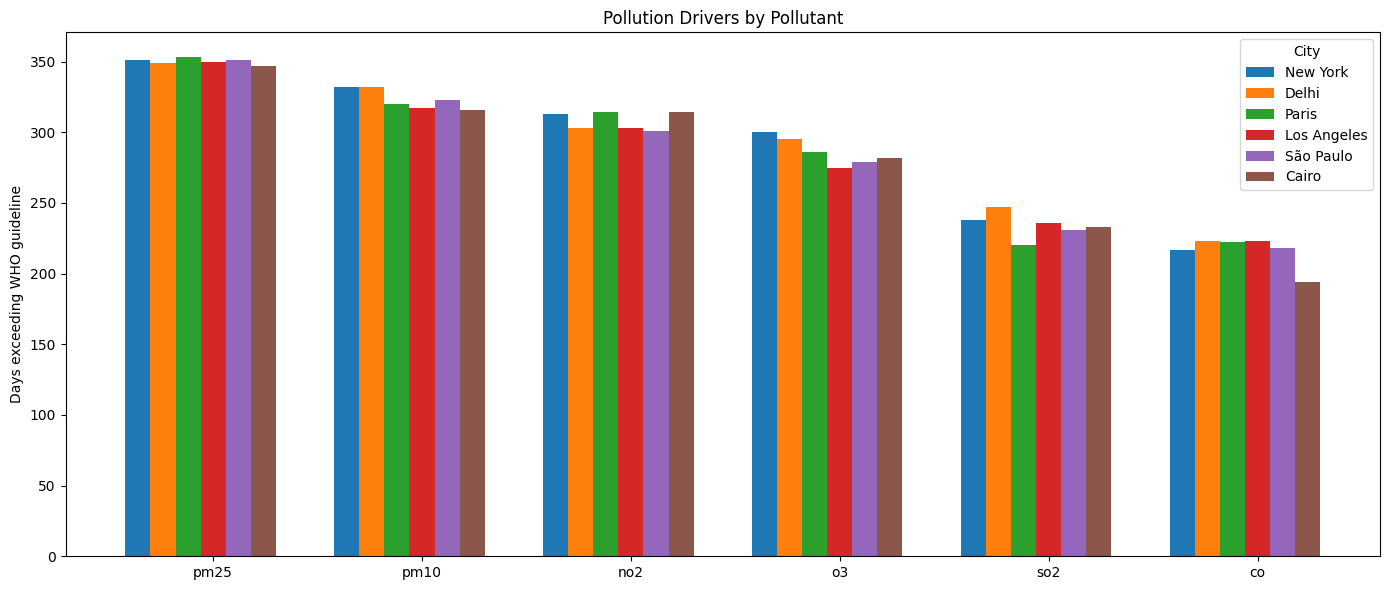

In [9]:
top_pollution_driver = queries.query_pollution_driver_per_city(
    start_date="2024-01-01",
    end_date="2024-12-31",
    limit=9
)

plot_pollution_driver_grouped_by_pollutant(top_pollution_driver)
